In [2]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load(knitr, tidyverse, ggplot2, dplyr, lubridate, stringr, readxl, data.table, gdata, scales, broom, stargazer, rdrobust, fixest)

Loading required package: pacman



In [3]:
file_list <- list.files(path = "../data/output", pattern = "data-.*\\.csv", full.names = TRUE)

# Read all csvs 2009-2019 into one data frame
hwk.data <- file_list %>%
map_df(~read_csv(., col_types = cols(provider_number = col_character()))) %>%
  mutate(year = as.numeric(year)) %>%  
  filter(year >= 2009 & year <= 2019)

### Question 1: From 2009-2019, how many hospitals filed more than one report in the same year?

In [4]:
# Load raw data
final.hcris.v1996 <- read_tsv('../data/input/HCRIS_Data_v1996.txt')
final.hcris.v2010 <- read_tsv('../data/input/HCRIS_Data_v2010.txt')

# Remerge
final.hcris <- bind_rows(final.hcris.v1996, final.hcris.v2010)

# Create the missing column again
final.hcris <- final.hcris %>%
  mutate(fyear = year(mdy(fy_end))) %>% 
    # creates total report column
  add_count(provider_number, fyear, name="total_reports") 

# Analysis for q1
q1_data <- final.hcris %>%
  filter(fyear >= 2009 & fyear <= 2019) %>%
  group_by(fyear) %>%
  summarize(mult_report_hospitals = n_distinct(provider_number[total_reports > 1]))

Rows: 78508 Columns: 47
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (12): provider_number, fy_start, fy_end, date_processed, date_created, d...
dbl (34): report, status, year, beds, tot_charges, net_pat_rev, tot_discount...
lgl  (1): npi

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 85496 Columns: 48
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (12): provider_number, fy_start, fy_end, date_processed, date_created, d...
dbl (35): report, status, year, beds, tot_charges, tot_discounts, net_pat_re...
lgl  (1): npi

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


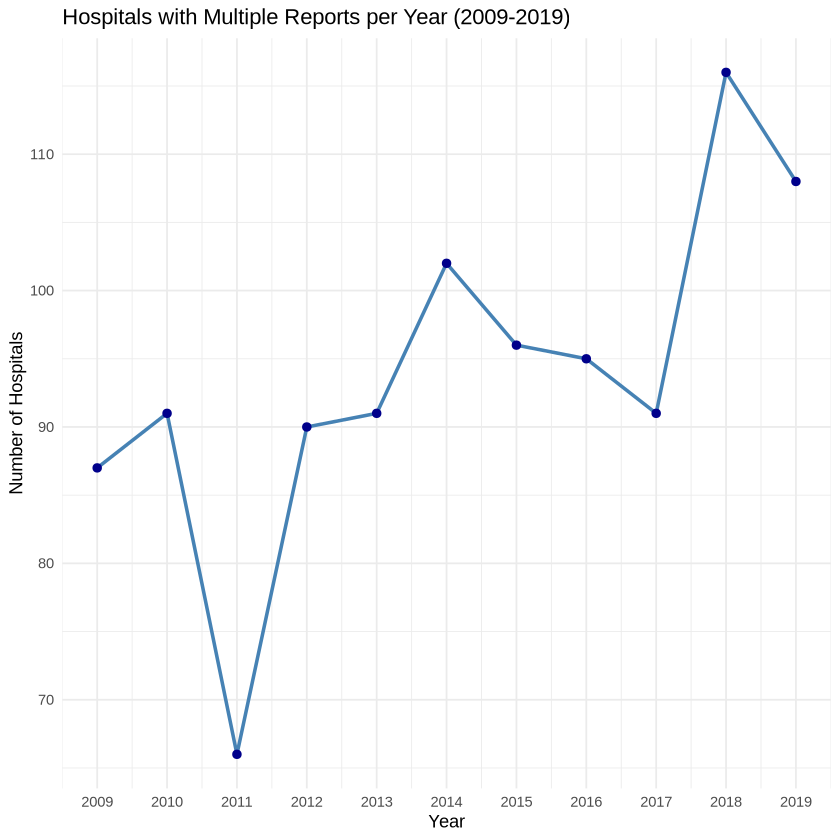

In [5]:
# Create line graph
ggplot(q1_data, aes(x = fyear, y = mult_report_hospitals)) +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_point(color = "darkblue", size = 2) +
  scale_x_continuous(breaks = 2009:2019) +
  theme_minimal() +
  labs(
    title = "Hospitals with Multiple Reports per Year (2009-2019)",
    x = "Year",
    y = "Number of Hospitals",
  )

### Question 2: After removing/combining multiple reports, how many unique hospital IDs (Medicare provider numbers) exist in the data?

In [6]:
unique_hospitals <- n_distinct(hwk.data$provider_number)
cat("Total unique Medicare provider numbers in cleaned data:", unique_hospitals, "\n")

Total unique Medicare provider numbers in cleaned data: 6897 


### Question 3: From 2009-2019, what is the distribution of total charges (tot_charges in the data) in each year? 

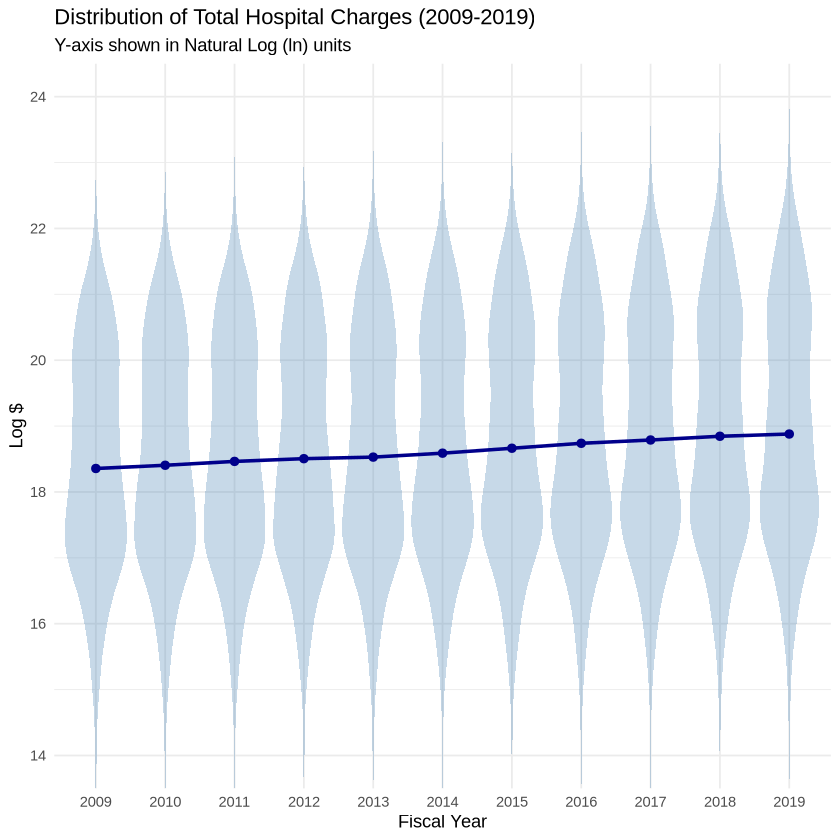

In [7]:
# Prep data
q3_plot_data <- hwk.data %>%
  filter(tot_charges > 0) %>%
  mutate(
    year_factor = as.factor(year),
    log_charges = log(tot_charges) # This creates the natural log (ln)
  )

# Create the plot
ggplot(q3_plot_data, aes(x = year_factor, y = log_charges)) +
geom_violin(fill = "steelblue", alpha = 0.3, color = NA) +
  
# Median points, trend line
stat_summary(fun = "median", geom = "point", color = "darkblue", size = 2) +
stat_summary(fun = "median", geom = "line", aes(group = 1), color = "darkblue", linewidth = 1) +

scale_y_continuous(breaks = seq(14, 24, 2)) + 
  
coord_cartesian(ylim = c(14, 24)) + 
  
theme_minimal() +
labs(
title = "Distribution of Total Hospital Charges (2009-2019)",
subtitle = "Y-axis shown in Natural Log (ln) units",
x = "Fiscal Year",
y = "Log $"
)

### Question 4: From 2009-2019, what is the distribution of estimated prices in each year?

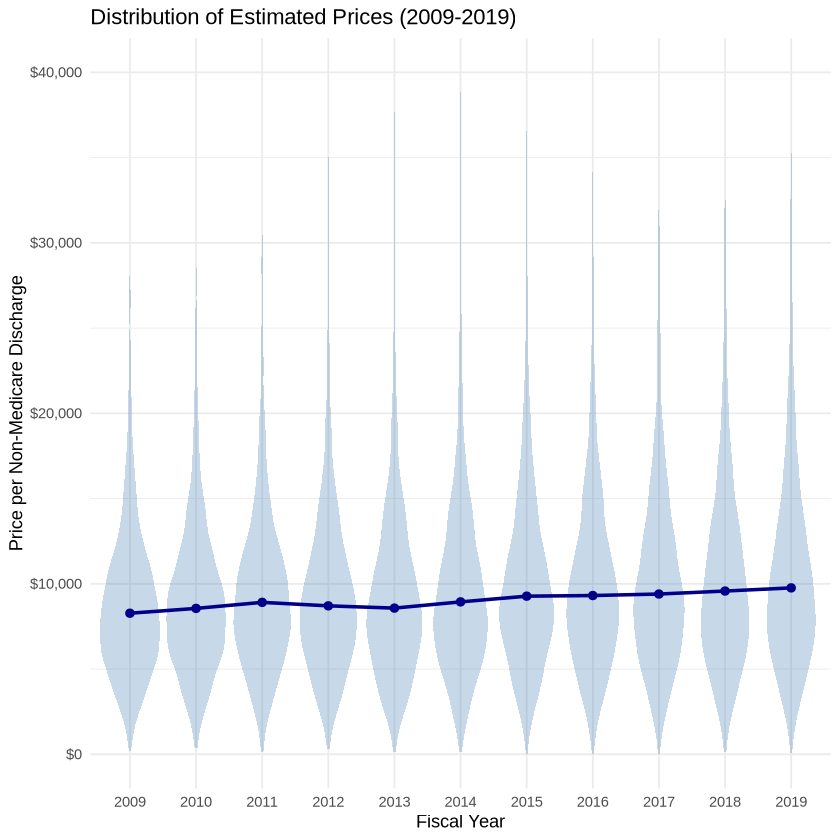

In [9]:
# Update main data frame with formulas
hwk.data <- hwk.data %>%
  mutate(
    discount_factor = 1 - (tot_discounts / tot_charges),
    discount_factor = ifelse(is.finite(discount_factor), discount_factor, 1),
    
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom
  )

# Filters / exclusion criteria
q4_plot_data <- hwk.data %>%
  filter(
    price_denom > 100, # Denominator > 100
    price_num >= 0, # No negative numerators
    price <= 100000, # Cap price at 100k
    price > 0, # Keep prices positive
    beds > 30 
  ) %>%
  mutate(year_factor = as.factor(year))

# 3. Create the plot
ggplot(q4_plot_data, aes(x = year_factor, y = price)) +
geom_violin(fill = "steelblue", alpha = 0.3, color = NA) +
  
# Median points & trend line
stat_summary(fun = "median", geom = "point", color = "darkblue", size = 2) +
stat_summary(fun = "median", geom = "line", aes(group = 1), color = "darkblue", linewidth = 1) +
  
# Use label_dollar for clarity
scale_y_continuous(labels = scales::label_dollar()) +
  
# Zooming in
coord_cartesian(ylim = c(0, 40000)) + 
  
theme_minimal() +
labs(
title = "Distribution of Estimated Prices (2009-2019)",
x = "Fiscal Year",
y = "Price per Non-Medicare Discharge"
)

### Question 5: What share of hospitals are penalized under the HRRP/VBP? (2012-2019)

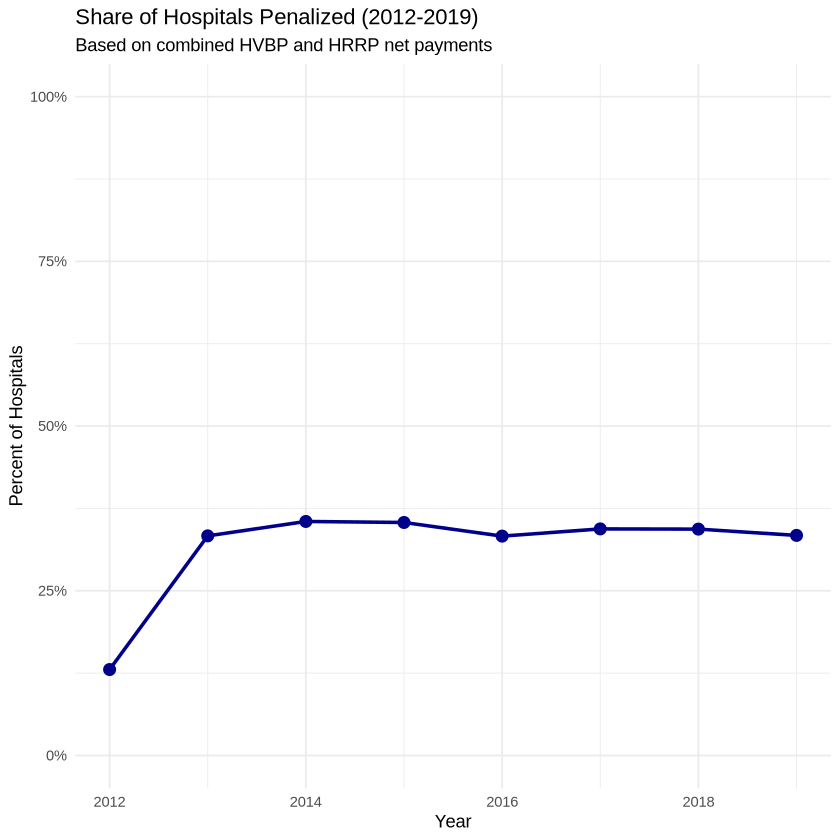

In [10]:
# Create penalty indicators
hwk.data <- hwk.data %>%
  mutate(
    hvbp_payment = ifelse(is.na(hvbp_payment), 0, hvbp_payment),
    hrrp_payment = ifelse(is.na(hrrp_payment), 0, abs(hrrp_payment)),
    
    # Calculate net penalty
    net_payment = hvbp_payment - hrrp_payment,
    
    # Binary indicator
    is_penalized = as.numeric(net_payment < 0)
    )

# Calculate share of penalized hospitals per year
q5_results <- hwk.data %>%
  filter(year >= 2012 & year <= 2019) %>%
  group_by(year) %>%
  summarize(
    total_hospitals = n(),
    penalized_count = sum(is_penalized, na.rm = TRUE),
    share_penalized = penalized_count / total_hospitals
  )

# Create plot
ggplot(q5_results, aes(x = year, y = share_penalized)) +
  geom_line(color = "darkblue", linewidth = 1) +
  geom_point(color = "darkblue", size = 3) +
  scale_y_continuous(labels = scales::percent, limits = c(0, 1)) +
  theme_minimal() +
  labs(
    title = "Share of Hospitals Penalized (2012-2019)",
    subtitle = "Based on combined HVBP and HRRP net payments",
    x = "Year",
    y = "Percent of Hospitals"
  )

### Question 6: Provide a summary of OLS estimates of the effect of net penalties on price changes.

In [15]:
iv_data <- hwk.data %>%
  filter(year >= 2009 & year <= 2014) %>%
  group_by(provider_number) %>%
  summarize(
    # Net payment from Q5
    penalty_amt = mean(net_payment[year == 2012], na.rm = TRUE),
    
    # Outcome: price change
    price_change = mean(price[year == 2014], na.rm = TRUE) - mean(price[year == 2011], na.rm = TRUE),
    
    # Instrument & Controls
    avg_mcare_disch = mean(mcare_discharges[year <= 2011], na.rm = TRUE),
    avg_beds = mean(beds[year <= 2011], na.rm = TRUE),
    avg_mcaid_disch = mean(mcaid_discharges[year <= 2011], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  # Clean
  filter(is.finite(price_change), 
         abs(price_change) < 50000, 
         avg_beds > 30)

# OLS
m1_ols <- feols(price_change ~ penalty_amt, data = iv_data)
m2_ols <- feols(price_change ~ penalty_amt + avg_beds, data = iv_data)
m3_ols <- feols(price_change ~ penalty_amt + avg_beds + avg_mcaid_disch, data = iv_data)

etable(m1_ols, m2_ols, m3_ols, tex = FALSE)

NOTE: 5 observations removed because of NA values (RHS: 5).

NOTE: 5 observations removed because of NA values (RHS: 5).

NOTE: 16 observations removed because of NA values (RHS: 16).



,,m1_ols,m2_ols,m3_ols
,<chr>,<chr>,<chr>,<chr>
1,Dependent Var.:,price_change,price_change,price_change
2,,,,
3,Constant,84.98 (75.02),66.95 (75.86),-65.01 (93.50)
4,penalty_amt,-0.0045* (0.0019),-0.0044* (0.0019),-0.0039* (0.0019)
5,avg_beds,,0.0751 (0.0476),0.0668 (0.0478)
6,avg_mcaid_disch,,,0.0842* (0.0350)
7,_______________,_________________,_________________,_________________
8,S.E. type,IID,IID,IID
9,Observations,"2,508","2,508","2,497"


### Question 7: Provide a scatterplot of net penalty against pre-2012 Medicare discharges.

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 611 rows containing non-finite values (`stat_smooth()`).”
Warning message:
“Removed 611 rows containing missing values (`geom_point()`).”


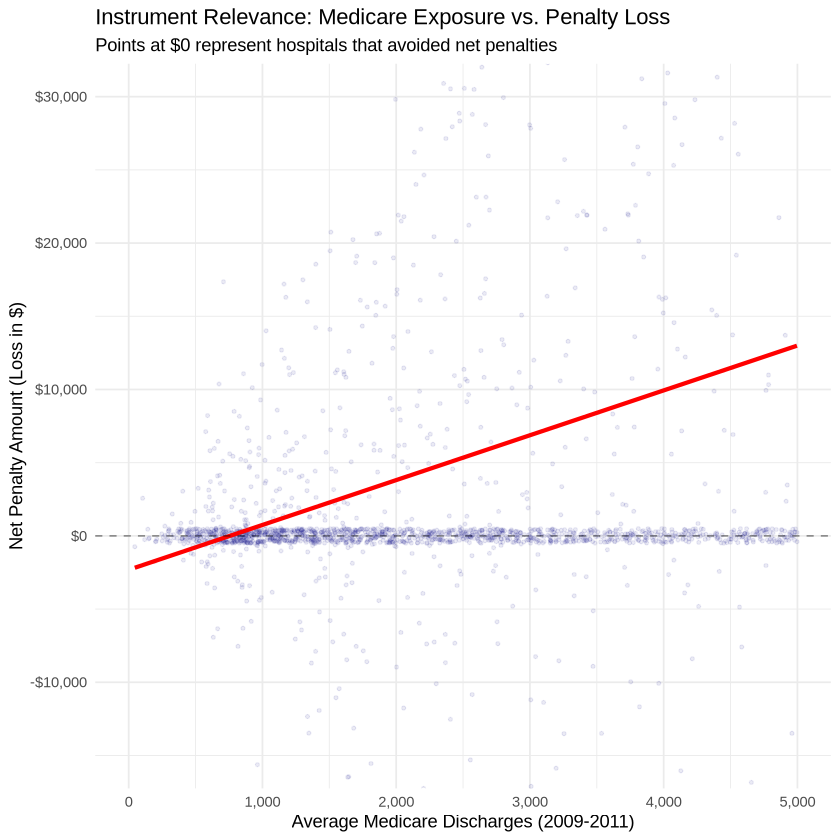

In [27]:
iv_data <- iv_data %>%
  mutate(
    penalty_loss = -penalty_amt
  )

ggplot(iv_data, aes(x = avg_mcare_disch, y = penalty_loss)) +
  geom_jitter(alpha = 0.08, color = "darkblue", size = 0.8, width = 0, height = 500) +
  
  geom_smooth(method = "lm", color = "red", se = FALSE, linewidth = 1.2) +
  
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", alpha = 0.4) +
  
  scale_x_continuous(labels = scales::comma, limits = c(0, 5000)) +
  scale_y_continuous(labels = scales::dollar) +
  coord_cartesian(ylim = c(-15000, 30000)) + 
  
  theme_minimal() +
  labs(
    title = "Instrument Relevance: Medicare Exposure vs. Penalty Loss",
    subtitle = "Points at $0 represent hospitals that avoided net penalties",
    x = "Average Medicare Discharges (2009-2011)",
    y = "Net Penalty Amount (Loss in $)"
  )

### Question 8: Provide a summary of the first stage and reduced-form results using pre-penalty Medicare discharges as an instrument for net penalties. 

In [35]:
# First stage models
fs_1 <- feols(penalty_amt ~ avg_mcare_disch, data = iv_data)
fs_2 <- feols(penalty_amt ~ avg_mcare_disch + avg_beds, data = iv_data)
fs_3 <- feols(penalty_amt ~ avg_mcare_disch + avg_beds + avg_mcaid_disch, data = iv_data)

# Reduced form models
rf_1 <- feols(price_change ~ avg_mcare_disch, data = iv_data)
rf_2 <- feols(price_change ~ avg_mcare_disch + avg_beds, data = iv_data)
rf_3 <- feols(price_change ~ avg_mcare_disch + avg_beds + avg_mcaid_disch, data = iv_data)

# Summary tables
etable(fs_1, fs_2, fs_3, 
       title = "Table 2: First Stage Results (Dep. Var: Net Penalty)",
       headers = c("Baseline", "+ Beds", "+ Medicaid"))

etable(rf_1, rf_2, rf_3, 
       title = "Table 3: Reduced Form Results (Dep. Var: Price Change)",
       headers = c("Baseline", "+ Beds", "+ Medicaid"))

NOTE: 5 observations removed because of NA values (LHS: 5).

NOTE: 5 observations removed because of NA values (LHS: 5).

NOTE: 17 observations removed because of NA values (LHS: 5, RHS: 12).

NOTE: 12 observations removed because of NA values (RHS: 12).



,,fs_1,fs_2,fs_3
,<chr>,<chr>,<chr>,<chr>
1,,Baseline,+ Beds,+ Medicaid
2,Dependent Var.:,penalty_amt,penalty_amt,penalty_amt
3,,,,
4,Constant,"-1,253.9*** (366.3)","-1,255.2*** (366.5)","-1,240.6*** (372.8)"
5,avg_mcare_disch,0.6567*** (0.0766),0.6557*** (0.0771),0.6720*** (0.0887)
6,avg_beds,,0.0197 (0.1576),0.0213 (0.1581)
7,avg_mcaid_disch,,,-0.0462 (0.1307)
8,_______________,___________________,___________________,___________________
9,S.E. type,IID,IID,IID


,,rf_1,rf_2,rf_3
,<chr>,<chr>,<chr>,<chr>
1,,Baseline,+ Beds,+ Medicaid
2,Dependent Var.:,price_change,price_change,price_change
3,,,,
4,Constant,"-1,123.2 (773.5)","-1,128.4 (773.9)",-326.7 (568.7)
5,avg_mcare_disch,0.3678* (0.1618),0.3637* (0.1627),0.2629. (0.1354)
6,avg_beds,,0.0798 (0.3332),0.0743 (0.2414)
7,avg_mcaid_disch,,,-0.0540 (0.1995)
8,_______________,________________,________________,________________
9,S.E. type,IID,IID,IID


### Question 9: Provide a summary of IV estimates of the effect of net penalties on price changes. 

In [28]:
# Baseline IV
m1_iv <- feols(price_change ~ 1 | penalty_amt ~ avg_mcare_disch, 
               data = iv_data)

# Baseline + Beds
m2_iv <- feols(price_change ~ avg_beds | penalty_amt ~ avg_mcare_disch, 
               data = iv_data)

# Baseline + Beds + Medicaid
m3_iv <- feols(price_change ~ avg_beds + avg_mcaid_disch | penalty_amt ~ avg_mcare_disch, 
               data = iv_data)

# Results
etable(m1_iv, m2_iv, m3_iv, 
       title = "Table 2: IV Estimates (2SLS) of Net Penalties on Price Changes",
       headers = c("Baseline", "+ Beds", "+ Medicaid"),
       fitstat = ~ f + n, # This shows the First-Stage F-stat and Sample Size
       tex = FALSE)

NOTE: 5 observations removed because of NA values (IV: 5/0).

NOTE: 5 observations removed because of NA values (IV: 5/0).

NOTE: 16 observations removed because of NA values (RHS: 11, IV: 5/0).



,,m1_iv,m2_iv,m3_iv
,<chr>,<chr>,<chr>,<chr>
1,,Baseline,+ Beds,+ Medicaid
2,Dependent Var.:,price_change,price_change,price_change
3,,,,
4,Constant,119.5 (89.62),108.5 (89.89),10.26 (99.90)
5,penalty_amt,-0.0008 (0.0056),0.0002 (0.0056),0.0088 (0.0058)
6,avg_beds,,0.0790. (0.0479),0.0752 (0.0483)
7,avg_mcaid_disch,,,0.1095** (0.0370)
8,_______________,________________,________________,_________________
9,S.E. type,IID,IID,IID


### Question 10: Briefly explain the “Local” ATE in the context of your estimates. How might a local effect differ from an overall ATE in this setting?

The IV estimate represents a Local ATE because it identifies the causal impact of net penalties on price changes specifically for the hospitals whose penalty status was directly influenced by their volume of Medicare discharges (the instrument).
UPDATE THIS W NEW VALUES The local effect ($0.3895$) is significantly larger and more statistically meaningful than the overall ATE estimated by OLS ($0.0058$).